# AQ-Chronos: Smart Air Quality Surveillance Across the Globe

## OpenAQ API Incorporation and Forecasting

OpenAQ is a non-profit envinronmental tech organization that aggregates global air quality data from various sensors into one open-source platform, providing free access to data on pollutants through an API and an interactive Explorer tool.

This data is analysed using the Prophet class, which allows to make predictions on a numerical quantity $y$ that is present on a dataframe by using the columns $y$ and $ds$, which instead represents a date or timestamp.

In [1]:
import pandas as pd
import requests
import os
import time
from dotenv import load_dotenv

load_dotenv()

API_KEY = os.getenv("OPENAQ_API_KEY")
HEADERS = {"X-API-Key": API_KEY}
LOCATION_IDS = {"New York - Brooklyn": 6091551,
               "Manaus": 5040030,
               "London - Westminster": 159,
               "Lagos - LASWA Five Cowries Terminal": 5350409,
               "Pretoria - North Suburb": 3021125,
               "Beijing - Chunxiu Lu": 2836346,
               "Osaka - 1-chōme-5-40 Kohama": 1214942,
               "Sydney": 2392564}
SENSOR_TYPE = "pm25"

if not API_KEY:
    raise ValueError("API Key not found! Please check your .env file.")

dataframes_list = [] # List to store the dataframe for each city.

for city, ID in LOCATION_IDS.items():
    print(f"--- Processing {city} (ID: {ID}) ---")
    try:
        # Get available sensors for each city.
        sensors_url = f"https://api.openaq.org/v3/locations/{ID}/sensors"
        res = requests.get(sensors_url, headers=HEADERS).json()
        if "results" not in res or not res["results"]:
            print(f"❌ No sensors found for {city}. Skipping.")
            continue
        available_params = [s["parameter"]["name"] for s in res["results"]]
        
        # Extract the sensor ID: PM2.5 or rely on a fallback.
        try:
            sensor_id = next(s['id'] for s in res['results'] if s['parameter']['name'].lower() == SENSOR_TYPE.lower())
            chosen_param = SENSOR_TYPE
            print(f"✅ Success! Found {SENSOR_TYPE} sensor in {city}.")
        except StopIteration:
            fallback_param = res["results"][0] # If PM2-5 is not available, take the first available sensor instead.
            sensor_id = fallback_param["id"]
            chosen_param = fallback_param["parameter"]["name"]
            print(f"⚠️ {SENSOR_TYPE} not found in {city}. Using fallback: {fallback_param}.")

        # Fetch measurements for the current sensor.
        measurements_url = f"https://api.openaq.org/v3/sensors/{sensor_id}/measurements"
        params = {"period_name": "hourly", "limit": 1000}
        data = requests.get(measurements_url, headers=HEADERS, params=params).json()
        if "results" in data and data["results"]:
            df_city = pd.DataFrame(data["results"])
            df_city["city"] = city # Add the city to identify data in the complete dataframe.
            df_city["parameter"] = chosen_param
            dataframes_list.append(df_city)
            print(f"📈 Fetched {len(df_city)} rows.")
        else:
            print(f"❌ No measurement data found for {city}.")
        
        time.sleep(0.5) # Introduce a small sleep to respect API rate limits.
    except Exception as e:
        print(f"❌ Error processing {city}: {e}")

# Create the complete dataframe.
if dataframes_list:
    df_final = pd.concat(dataframes_list, ignore_index=True)
    print("\n" + "="*30)
    print(f"✅ SUCCESS: Master DataFrame created.")
    print(f"Total rows: {len(df_final)}")
    print(f"Cities included: {df_final['city'].unique().tolist()}")
    print("="*30)
else:
    print("❌ No data was collected.")

# Display first few rows.
df_final.head()

--- Processing New York - Brooklyn (ID: 6091551) ---
✅ Success! Found pm25 sensor in New York - Brooklyn.
📈 Fetched 1000 rows.
--- Processing Manaus (ID: 5040030) ---
✅ Success! Found pm25 sensor in Manaus.
📈 Fetched 1000 rows.
--- Processing London - Westminster (ID: 159) ---
✅ Success! Found pm25 sensor in London - Westminster.
📈 Fetched 1000 rows.
--- Processing Lagos - LASWA Five Cowries Terminal (ID: 5350409) ---
✅ Success! Found pm25 sensor in Lagos - LASWA Five Cowries Terminal.
📈 Fetched 1000 rows.
--- Processing Pretoria - North Suburb (ID: 3021125) ---
✅ Success! Found pm25 sensor in Pretoria - North Suburb.
📈 Fetched 1000 rows.
--- Processing Beijing - Chunxiu Lu (ID: 2836346) ---
✅ Success! Found pm25 sensor in Beijing - Chunxiu Lu.
📈 Fetched 1000 rows.
--- Processing Osaka - 1-chōme-5-40 Kohama (ID: 1214942) ---
✅ Success! Found pm25 sensor in Osaka - 1-chōme-5-40 Kohama.
📈 Fetched 1000 rows.
--- Processing Sydney (ID: 2392564) ---
✅ Success! Found pm25 sensor in Sydney.
📈

,value,flagInfo,parameter,period,coordinates,summary,coverage,city
0,6.572833,{'hasFlags': False},pm25,"{'label': 'raw', 'interval': '01:00:00', 'date...",None,None,"{'expectedCount': 1, 'expectedInterval': '01:0...",New York - Brooklyn
1,9.558750,{'hasFlags': False},pm25,"{'label': 'raw', 'interval': '01:00:00', 'date...",None,None,"{'expectedCount': 1, 'expectedInterval': '01:0...",New York - Brooklyn
2,21.638667,{'hasFlags': False},pm25,"{'label': 'raw', 'interval': '01:00:00', 'date...",None,None,"{'expectedCount': 1, 'expectedInterval': '01:0...",New York - Brooklyn
3,7.058125,{'hasFlags': False},pm25,"{'label': 'raw', 'interval': '01:00:00', 'date...",None,None,"{'expectedCount': 1, 'expectedInterval': '01:0...",New York - Brooklyn
4,3.257625,{'hasFlags': False},pm25,"{'label': 'raw', 'interval': '01:00:00', 'date...",None,None,"{'expectedCount': 1, 'expectedInterval': '01:0...",New York - Brooklyn


In [2]:
# Diagnostic to see the exact structure.
if not df_final.empty:
    print("Columns:", df_final.columns.tolist())
    print("\nFirst row contents:")
    import json
    print(json.dumps(df_final.iloc[0].to_dict(), indent=2, default=str))
else:
    print("df_final is empty. Run Cell 1 again.")

Columns: ['value', 'flagInfo', 'parameter', 'period', 'coordinates', 'summary', 'coverage', 'city']

First row contents:
{
  "value": 6.572833283742269,
  "flagInfo": {
    "hasFlags": false
  },
  "parameter": "pm25",
  "period": {
    "label": "raw",
    "interval": "01:00:00",
    "datetimeFrom": {
      "utc": "2025-10-11T15:00:00Z",
      "local": "2025-10-11T11:00:00-04:00"
    },
    "datetimeTo": {
      "utc": "2025-10-11T16:00:00Z",
      "local": "2025-10-11T12:00:00-04:00"
    }
  },
  "coordinates": null,
  "summary": null,
  "coverage": {
    "expectedCount": 1,
    "expectedInterval": "01:00:00",
    "observedCount": 1,
    "observedInterval": "01:00:00",
    "percentComplete": 100.0,
    "percentCoverage": 100.0,
    "datetimeFrom": {
      "utc": "2025-10-11T15:00:00Z",
      "local": "2025-10-11T11:00:00-04:00"
    },
    "datetimeTo": {
      "utc": "2025-10-11T16:00:00Z",
      "local": "2025-10-11T12:00:00-04:00"
    }
  },
  "city": "New York - Brooklyn"
}


In [3]:
# Remember to map cities to their respective timezones in order to properly analyse local daily patterns.
CITY_TIMEZONES = {"New York - Brooklyn": "America/New_York",
                  "Manaus": "America/Manaus",
                  "London - Westminster": "Europe/London",
                  "Lagos - LASWA Five Cowries Terminal": "Africa/Lagos",
                  "Pretoria - North Suburb": "Africa/Johannesburg",
                  "Beijing - Chunxiu Lu": "Asia/Shanghai",
                  "Osaka - 1-chōme-5-40 Kohama": "Asia/Tokyo",
                  "Sydney": "Australia/Sydney"}
df_processed = df_final.copy()
df_processed["ds"] = pd.to_datetime(df_processed["period"].apply(lambda x: x.get("datetimeFrom", {}).get("utc") if isinstance(x, dict) else None))
df_processed["y"] = pd.to_numeric(df_processed["value"], errors="coerce")

# Clean and filter the dataset by removing null values or outliers.
df_processed = df_processed.dropna(subset=["ds", "y", "city"]).copy()
df_processed = df_processed[(df_processed["y"] >= 0) & (df_processed["y"] < 1000)]

def convert_timezone(row):
    tz = CITY_TIMEZONES.get(row["city"], "UTC") # Use UTC as a default.
    return row["ds"].tz_convert(tz).tz_localize(None)

print("--- Converting timezones for each city ---")

df_processed["ds"] = df_processed.apply(convert_timezone, axis=1)

# Group data by DS and city to avoid mixing up data from different cities.
df_prophet_master = df_processed.groupby(["ds", "city"], as_index=False).agg({"y": "mean", "parameter": "first"})

df_prophet_master = df_prophet_master.sort_values(["city", "ds"])

if not df_prophet_master.empty:
    print(f"✅ SUCCESS: {len(df_prophet_master)} total rows ready!")
    for city in df_prophet_master["city"].unique():
        city_count = len(df_prophet_master[df_prophet_master["city"] == city])
        print(f"  - {city}: {city_count} rows")
else:
    print("❌ Error: No data processed.")

--- Converting timezones for each city ---
✅ SUCCESS: 7998 total rows ready!
  - Beijing - Chunxiu Lu: 1000 rows
  - Lagos - LASWA Five Cowries Terminal: 999 rows
  - London - Westminster: 1000 rows
  - Manaus: 1000 rows
  - New York - Brooklyn: 999 rows
  - Osaka - 1-chōme-5-40 Kohama: 1000 rows
  - Pretoria - North Suburb: 1000 rows
  - Sydney: 1000 rows


/home/gianmaria/Code/Jupyter/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


--- Modeling for Beijing - Chunxiu Lu ---


13:36:23 - cmdstanpy - INFO - Chain [1] start processing
13:36:23 - cmdstanpy - INFO - Chain [1] done processing


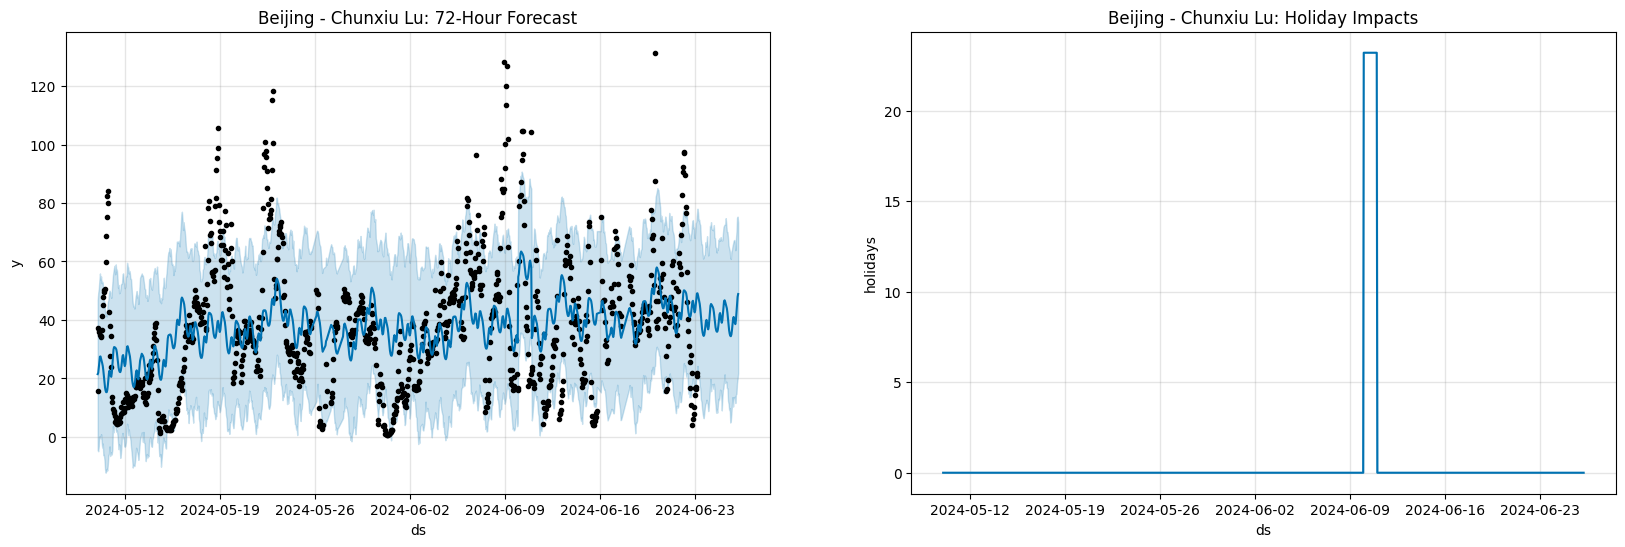

--- Modeling for Lagos - LASWA Five Cowries Terminal ---


13:36:24 - cmdstanpy - INFO - Chain [1] start processing
13:36:24 - cmdstanpy - INFO - Chain [1] done processing


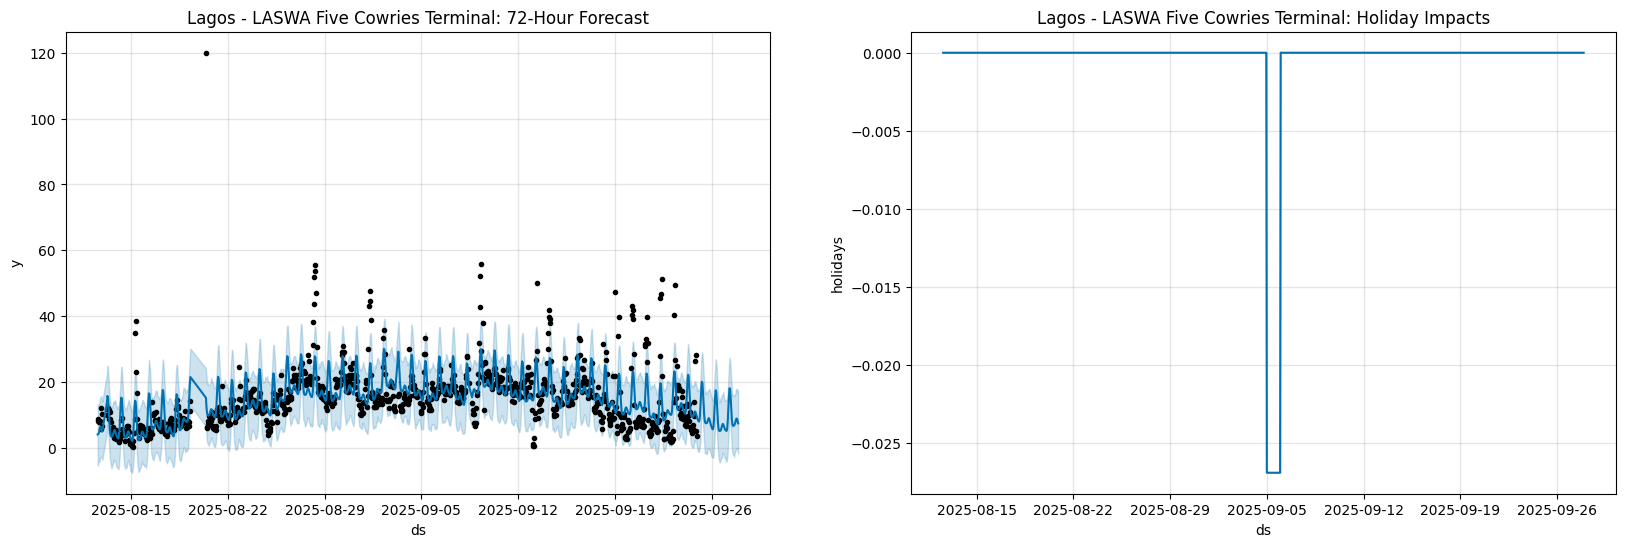

--- Modeling for London - Westminster ---


13:36:25 - cmdstanpy - INFO - Chain [1] start processing
13:36:26 - cmdstanpy - INFO - Chain [1] done processing


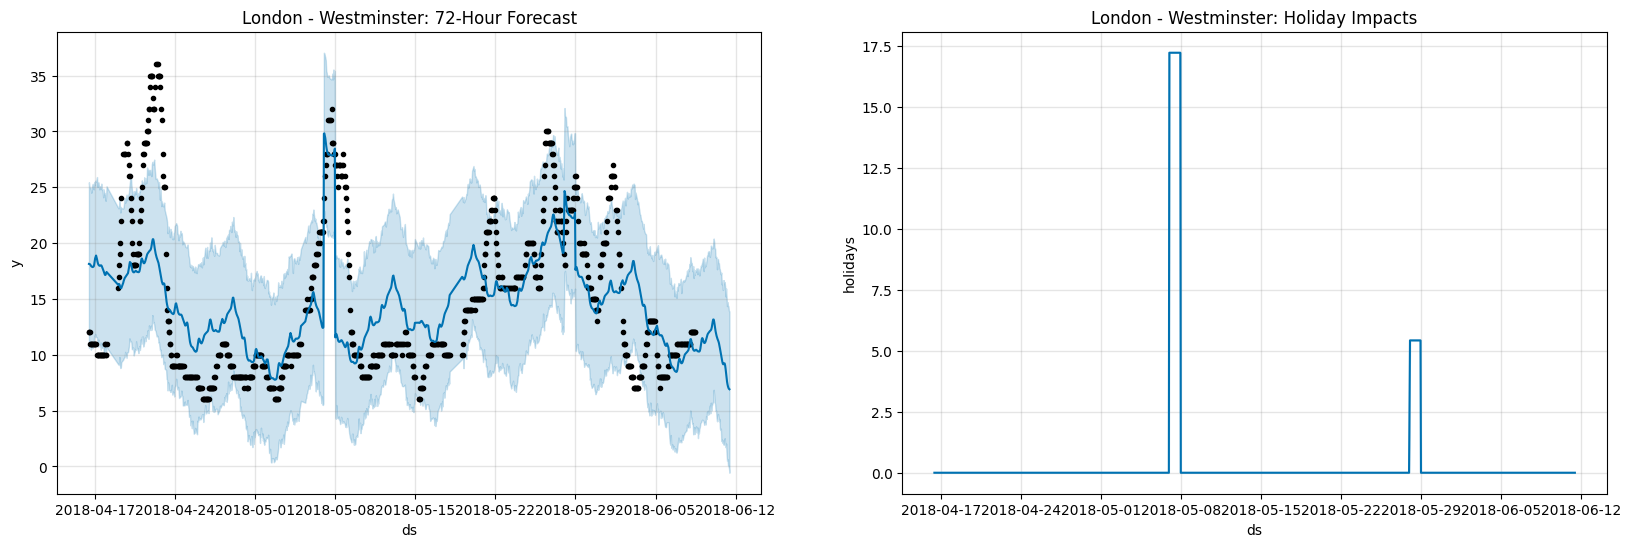

13:36:27 - cmdstanpy - INFO - Chain [1] start processing


--- Modeling for Manaus ---


13:36:27 - cmdstanpy - INFO - Chain [1] done processing


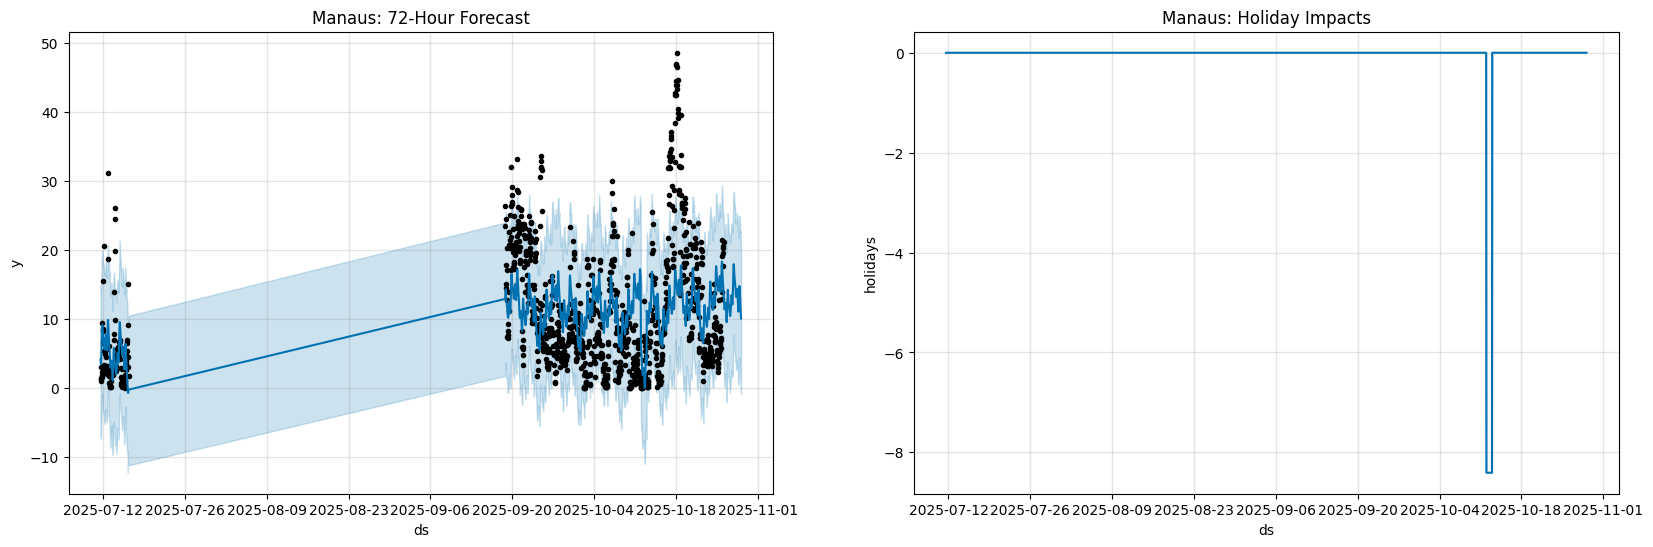

13:36:28 - cmdstanpy - INFO - Chain [1] start processing


--- Modeling for New York - Brooklyn ---


13:36:28 - cmdstanpy - INFO - Chain [1] done processing


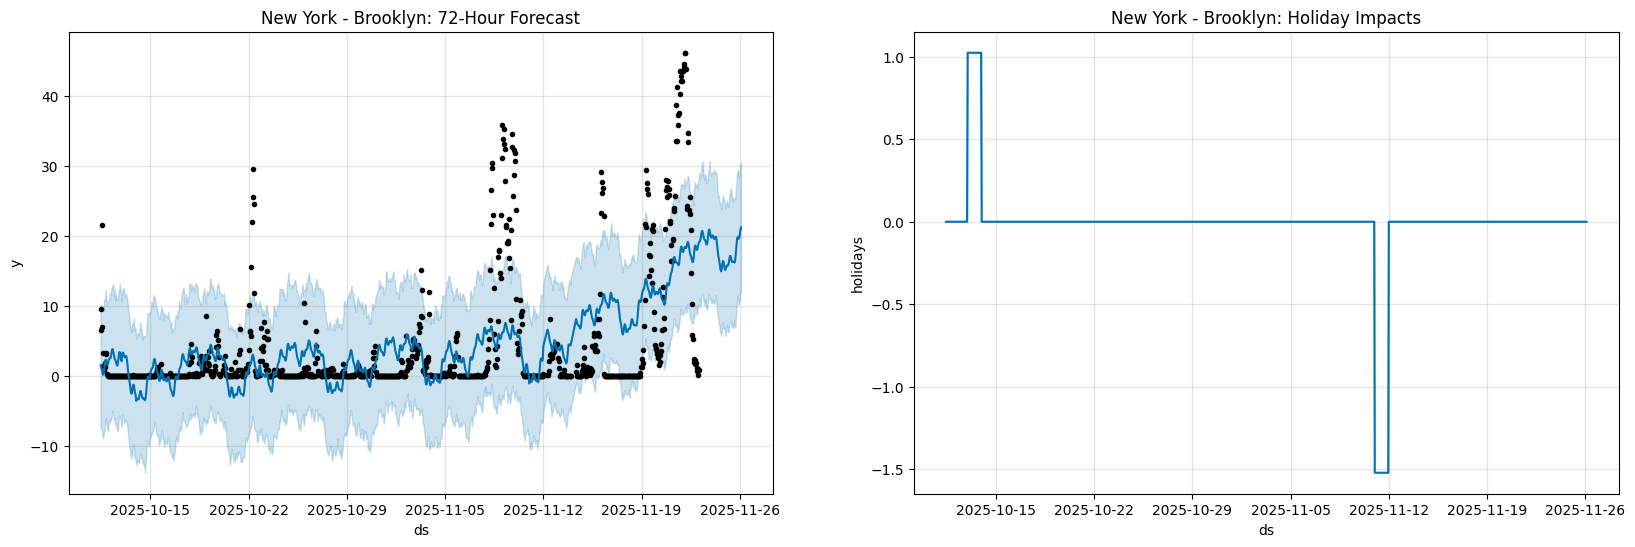

--- Modeling for Osaka - 1-chōme-5-40 Kohama ---


13:36:29 - cmdstanpy - INFO - Chain [1] start processing
13:36:29 - cmdstanpy - INFO - Chain [1] done processing


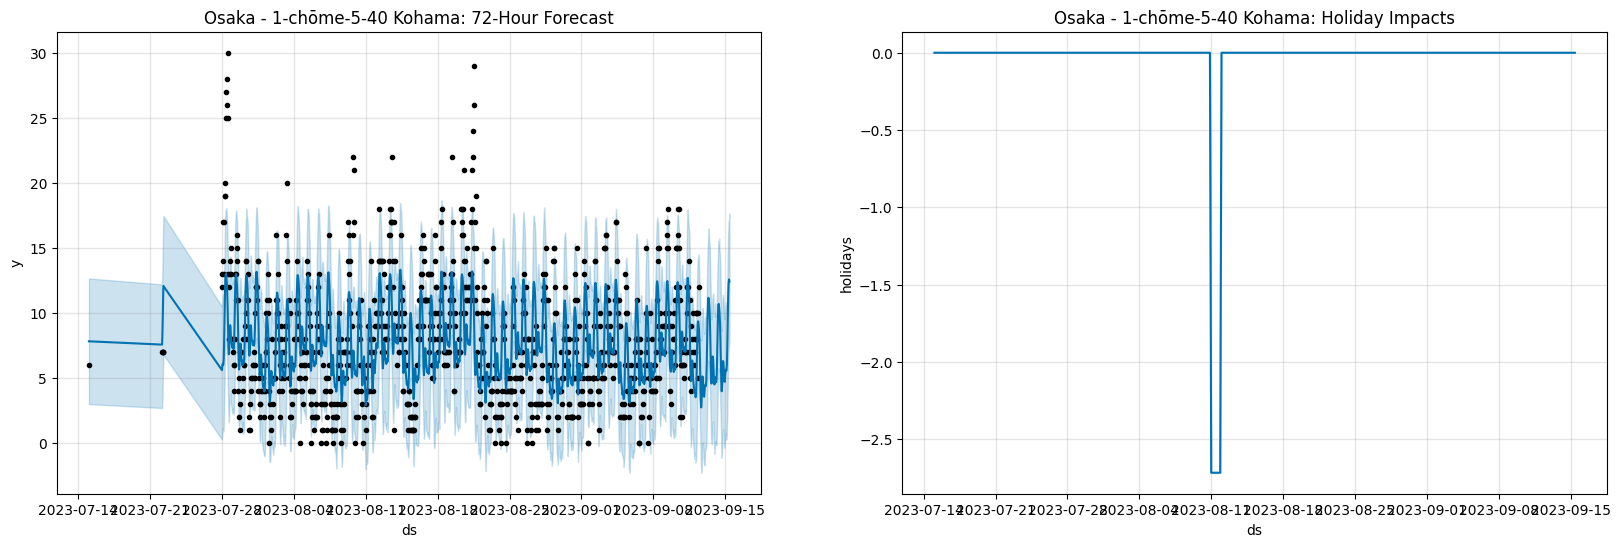

--- Modeling for Pretoria - North Suburb ---


13:36:31 - cmdstanpy - INFO - Chain [1] start processing
13:36:31 - cmdstanpy - INFO - Chain [1] done processing


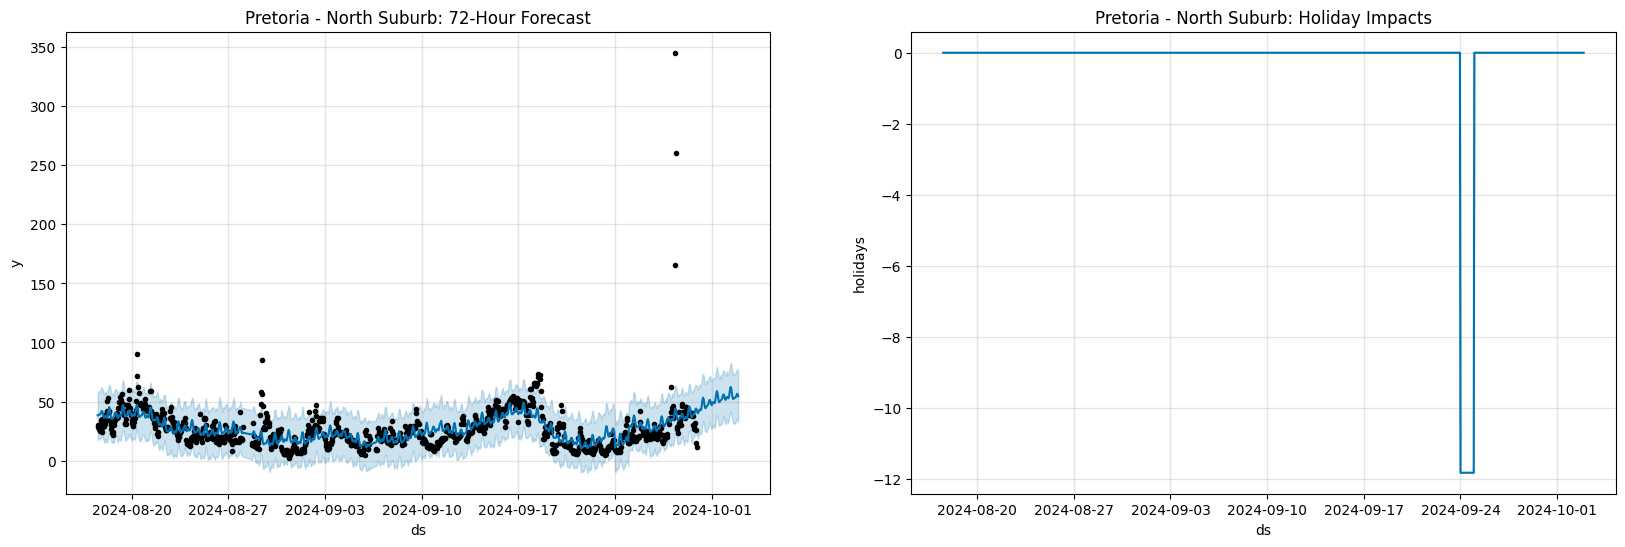

13:36:32 - cmdstanpy - INFO - Chain [1] start processing


--- Modeling for Sydney ---


13:36:32 - cmdstanpy - INFO - Chain [1] done processing


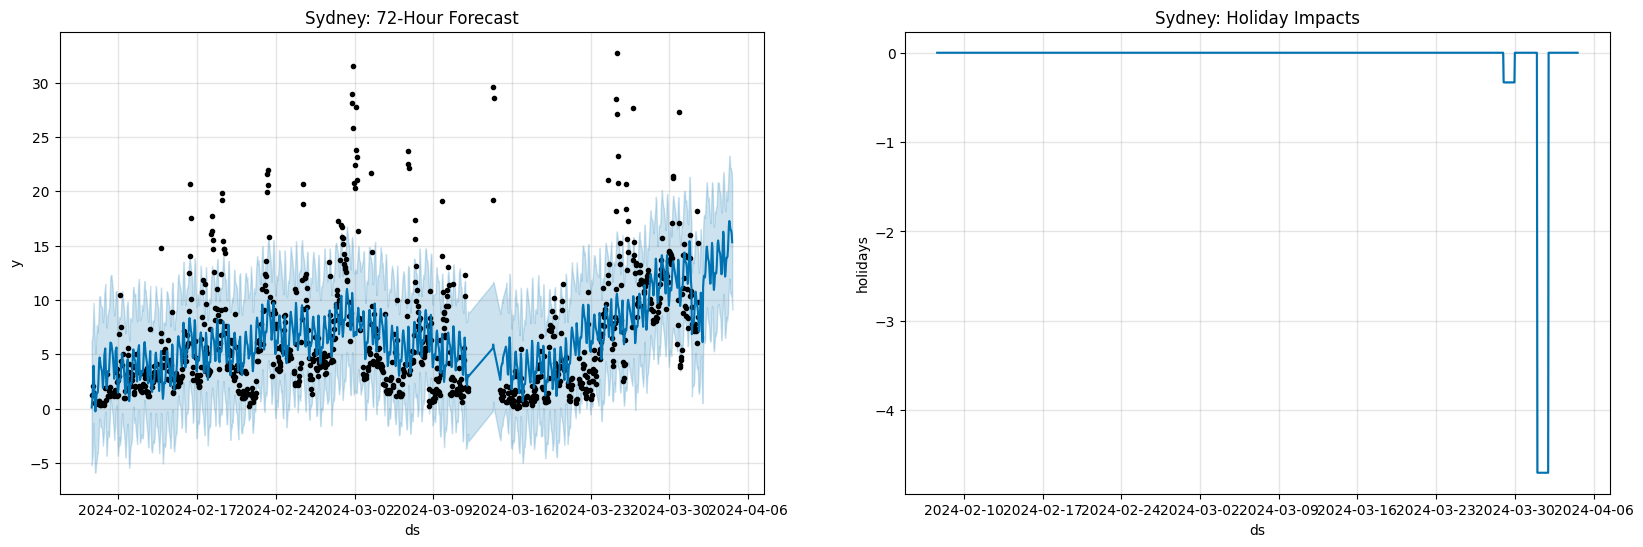

In [4]:
import matplotlib.pyplot as plt
from prophet import Prophet

# Map cities to the corresponding country codes in order to extract national holidays.
CITY_TO_COUNTRY = {"New York - Brooklyn": "US",
                   "Manaus": "BR",
                   "London - Westminster": "GB",
                   "Lagos - LASWA Five Cowries Terminal": "NG",
                   "Pretoria - North Suburb": "ZA",
                   "Beijing - Chunxiu Lu": "CN",
                   "Osaka - 1-chōme-5-40 Kohama": "JP",
                   "Sydney": "AU"}

all_forecasts = {} # Dictionary to store results for later comparisons.
all_models = {} # Dictionary to store models for evaluation.

for city in df_prophet_master["city"].unique():
    print(f"--- Modeling for {city} ---")
    city_data = df_prophet_master[df_prophet_master["city"] == city][["ds", "y"]] # Extract data only for the current city.
    model = Prophet(
        changepoint_prior_scale=0.05,
        daily_seasonality=True,
        weekly_seasonality=True
    )

    # Add holidays for the current country.
    country_code = CITY_TO_COUNTRY.get(city)
    if country_code:
        try:
            model.add_country_holidays(country_name=country_code)
        except Exception as e:
            print(f"⚠️ Holidays not supported for {country_code}: {e}")

    # Fit the model and use it to make predictions for the near future.
    model.fit(city_data)
    all_models[city] = model
    
    future = model.make_future_dataframe(periods=72, freq="h") # Get predictions for the next 72 hours.
    forecast = model.predict(future)
    all_forecasts[city] = forecast
    
    # Plot the results gathered for the current city.
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
    model.plot(forecast, ax=ax1)
    ax1.set_title(f"{city}: 72-Hour Forecast")

    # If available, plot additional components, such as holidays.
    if model.train_holiday_names is not None:
        from prophet.plot import plot_forecast_component
        plot_forecast_component(model, forecast, 'holidays', ax=ax2)
        ax2.set_title(f"{city}: Holiday Impacts")
    
    plt.show()

## Further Insights

### Geospatial Mapping

Folium is a Python library that allows to visualized processed/manipulated data on an interactive leaflet, such as a choroplet map or a HTML visualization on a map.

In [5]:
import folium
from folium import plugins

# Save coordinates for each city.
CITY_COORDINATES = {"New York - Brooklyn": [40.67248, -73.9588],
                   "Manaus": [-3.12089, -60.0214],
                   "London - Westminster": [51.49466, -0.13192],
                   "Lagos - LASWA Five Cowries Terminal": [6.44233, 3.42743],
                   "Pretoria - North Suburb": [-25.7101, 28.1726],
                   "Beijing - Chunxiu Lu": [39.93788, 116.44341],
                   "Osaka - 1-chōme-5-40 Kohama": [34.61944, 135.49305],
                   "Sydney": [-33.88773, 151.21503]}

# Initialize the map.
m = folium.Map(
    location=[15, 0],
    zoom_start=2,
    tiles=None,
    no_wrap=True,
    world_copy_jump=False
)

# Create a new tile layer to ensure the map does not wrap.
folium.TileLayer(
    "CartoDB dark_matter", 
    no_wrap=True
).add_to(m)

# Set maximum scrolling bounds.
m.fit_bounds([[-90, -180], [90, 180]])
m.options['maxBounds'] = [[-90, -180], [90, 180]]

def aq_color(value):
    if value <= 12:
        return "#00e400" # Good air quality.
    if value <= 35:
        return "#ffff00" # Moderate air quality.
    if value <= 55:
        return "#ff7e00" # Slightly unhealthy air quality.
    else:
        return "#ff0000" # Unhealthy air quality.

for city, coordinates in CITY_COORDINATES.items():
    city_data = df_prophet_master[df_prophet_master["city"] == city] # Extract data only for the current city.

    if not city_data.empty:
        # Get the latest value from the data.
        latest_val = city_data["y"].iloc[-1]
        latest_time = city_data["ds"].iloc[-1].strftime("%Y-%m-%d %H:%M")
        param = city_data["parameter"].iloc[-1]

        # Add a circle marker with dynamic coloring.
        folium.CircleMarker(
            location=coordinates,
            radius=15,
            popup=folium.Popup(f"""
                <div style="font-family: Arial; width: 200px;">
                    <h4>{city}</h4>
                    <hr>
                    <b>{param.upper()}:</b> {latest_val:.2f} µg/m³<br>
                    <b>Status:</b> {'OK' if latest_val < 25 else 'High'}<br>
                    <small>Updated: {latest_time}</small>
                </div>
            """, max_width=250),
            tooltip=f"{city}: {latest_val:.2f} $\mu g/m^3$",
            color="white",
            weight=1,
            fill=True,
            fill_color=aq_color(latest_val),
            fill_opacity=0.8
        ).add_to(m)

# Implement additional functionalities for the map.
plugins.Fullscreen(position="topright").add_to(m)

# Save the map.
output_path = os.path.join("..", "aq_chronos_air_map.html") # To ensure the map is saved in the main project directory.
m.save(output_path)
print("✅ Air Quality map generated successfully!")

✅ Air Quality map generated successfully!


### Model Diagnostics

The model's forecasts are evaluated using Time Series Cross-Validation, focusing on the Root Mean Squared Error across a 24-hour horizon to assess whether the model's warning are accurate.

--- Validating Beijing - Chunxiu Lu ---


Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
13:37:52 - cmdstanpy - INFO - Chain [1] start processing
13:37:52 - cmdstanpy - INFO - Chain [1] start processing
13:37:52 - cmdstanpy - INFO - Chain [1] done processing
13:37:52 - cmdstanpy - INFO - Chain [1] start processing
13:37:52 - cmdstanpy - INFO - Chain [1] done processing
13:37:52 - cmdstanpy - INFO - Chain [1] done processing
13:37:52 - cmdstanpy - INFO - Chain [1] start processing
13:37:52 - cmdstanpy - INFO - Chain [1] done processing
13:37:52 - cmdstanpy - INFO - Chain [1] start processing
13:37:52 - cmdstanpy - INFO - Chain [1] start processing
13:37:52 - cmdstanpy - INFO - Chain [1] start processing
13:37:52 - cmdstanpy - INFO - Chain [1] done processing
13:37:52 - cmdstanpy - INFO - Chain [1] done processing
13:37:52 - cmdstanpy - INFO - Cha

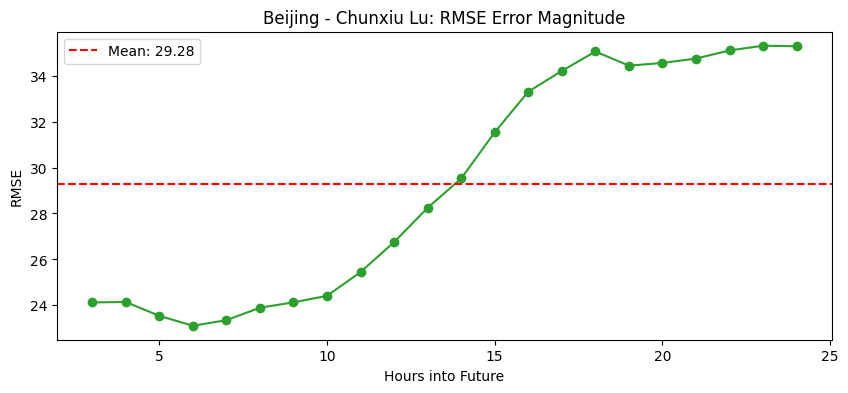

--- Validating Lagos - LASWA Five Cowries Terminal ---


Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
13:38:03 - cmdstanpy - INFO - Chain [1] start processing
13:38:03 - cmdstanpy - INFO - Chain [1] done processing
13:38:03 - cmdstanpy - INFO - Chain [1] start processing
13:38:03 - cmdstanpy - INFO - Chain [1] done processing
13:38:03 - cmdstanpy - INFO - Chain [1] start processing
13:38:03 - cmdstanpy - INFO - Chain [1] done processing
13:38:03 - cmdstanpy - INFO - Chain [1] start processing
13:38:03 - cmdstanpy - INFO - Chain [1] done processing
13:38:04 - cmdstanpy - INFO - Chain [1] start processing
13:38:04 - cmdstanpy - INFO - Chain [1] done processing
13:38:04 - cmdstanpy - INFO - Chain [1] start processing
13:38:04 - cmdstanpy - INFO - Chain [1] start processing
13:38:04 - cmdstanpy - INFO - Chain [1] done processing
13:38:04 - cmdstanpy - INFO - Cha

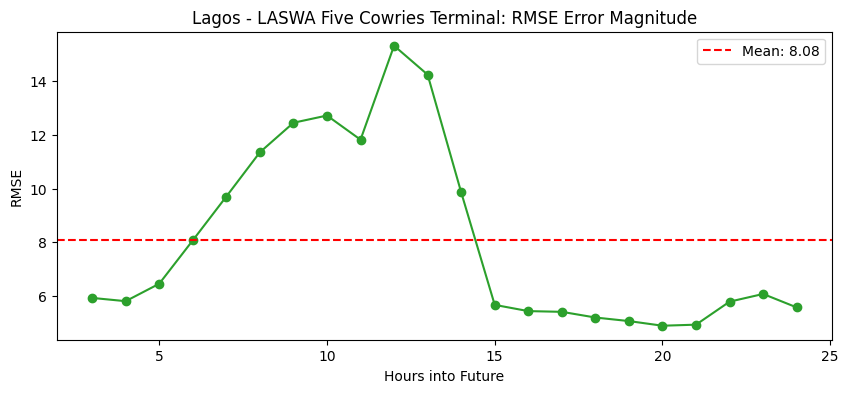

--- Validating London - Westminster ---


Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
13:38:14 - cmdstanpy - INFO - Chain [1] start processing
13:38:14 - cmdstanpy - INFO - Chain [1] done processing
13:38:14 - cmdstanpy - INFO - Chain [1] start processing
13:38:14 - cmdstanpy - INFO - Chain [1] start processing
13:38:14 - cmdstanpy - INFO - Chain [1] done processing
13:38:14 - cmdstanpy - INFO - Chain [1] start processing
13:38:14 - cmdstanpy - INFO - Chain [1] done processing
13:38:14 - cmdstanpy - INFO - Chain [1] done processing
13:38:14 - cmdstanpy - INFO - Chain [1] start processing
13:38:14 - cmdstanpy - INFO - Chain [1] start processing
13:38:14 - cmdstanpy - INFO - Chain [1] done processing
13:38:14 - cmdstanpy - INFO - Chain [1] start processing
13:38:14 - cmdstanpy - INFO - Chain [1] start processing
13:38:14 - cmdstanpy - INFO - Ch

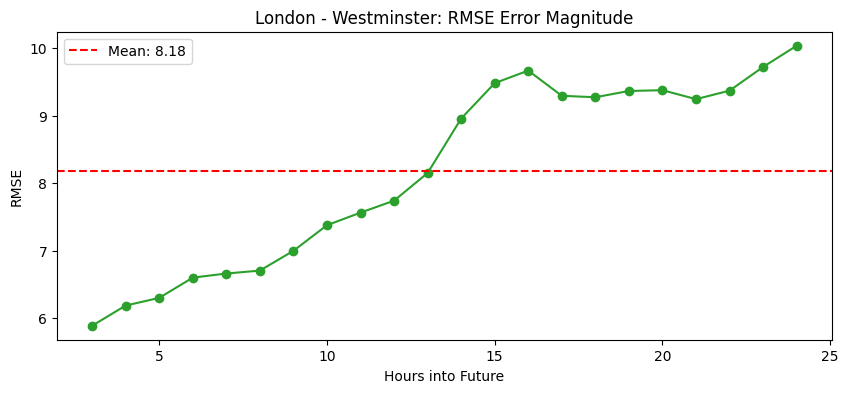

--- Validating Manaus ---


Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
13:38:26 - cmdstanpy - INFO - Chain [1] start processing
13:38:26 - cmdstanpy - INFO - Chain [1] done processing
13:38:26 - cmdstanpy - INFO - Chain [1] start processing
13:38:26 - cmdstanpy - INFO - Chain [1] start processing
13:38:26 - cmdstanpy - INFO - Chain [1] done processing
13:38:26 - cmdstanpy - INFO - Chain [1] done processing
13:38:26 - cmdstanpy - INFO - Chain [1] start processing
13:38:26 - cmdstanpy - INFO - Chain [1] done processing
13:38:27 - cmdstanpy - INFO - Chain [1] start processing
13:38:27 - cmdstanpy - INFO - Chain [1] done processing
13:38:27 - cmdstanpy - INFO - Chain [1] start processing
13:38:27 - cmdstanpy - INFO - Chain [1] start processing
13:38:27 - cmdstanpy - INFO - Chain [1] done processing
13:38:27 - cmdstanpy - INFO - Cha

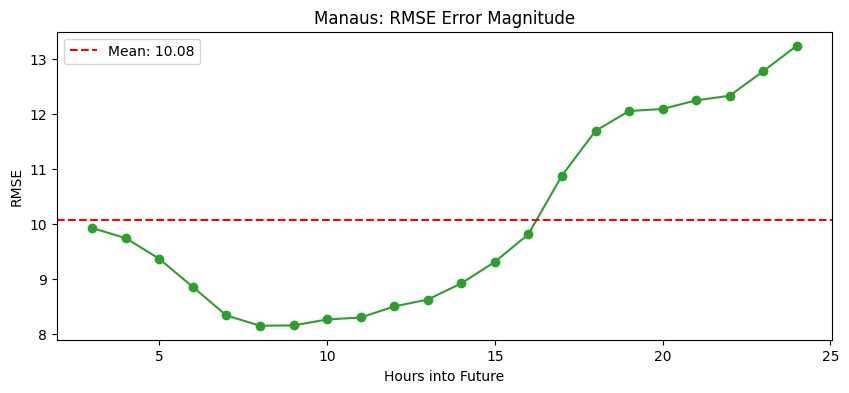

--- Validating New York - Brooklyn ---


Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
13:38:37 - cmdstanpy - INFO - Chain [1] start processing
13:38:37 - cmdstanpy - INFO - Chain [1] done processing
13:38:37 - cmdstanpy - INFO - Chain [1] start processing
13:38:37 - cmdstanpy - INFO - Chain [1] done processing
13:38:37 - cmdstanpy - INFO - Chain [1] start processing
13:38:37 - cmdstanpy - INFO - Chain [1] start processing
13:38:38 - cmdstanpy - INFO - Chain [1] done processing
13:38:38 - cmdstanpy - INFO - Chain [1] done processing
13:38:38 - cmdstanpy - INFO - Chain [1] start processing
13:38:38 - cmdstanpy - INFO - Chain [1] start processing
13:38:38 - cmdstanpy - INFO - Chain [1] done processing
13:38:38 - cmdstanpy - INFO - Chain [1] done processing
13:38:38 - cmdstanpy - INFO - Chain [1] start processing
13:38:38 - cmdstanpy - INFO - Cha

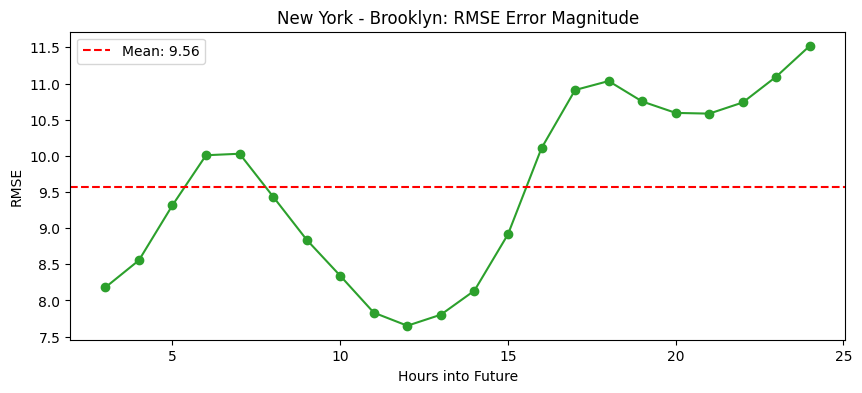

--- Validating Osaka - 1-chōme-5-40 Kohama ---


Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
13:38:48 - cmdstanpy - INFO - Chain [1] start processing
13:38:48 - cmdstanpy - INFO - Chain [1] start processing
13:38:48 - cmdstanpy - INFO - Chain [1] start processing
13:38:48 - cmdstanpy - INFO - Chain [1] start processing
13:38:48 - cmdstanpy - INFO - Chain [1] done processing
13:38:48 - cmdstanpy - INFO - Chain [1] done processing
13:38:48 - cmdstanpy - INFO - Chain [1] done processing
13:38:48 - cmdstanpy - INFO - Chain [1] start processing
13:38:49 - cmdstanpy - INFO - Chain [1] start processing
13:38:49 - cmdstanpy - INFO - Chain [1] done processing
13:38:49 - cmdstanpy - INFO - Chain [1] start processing
13:38:49 - cmdstanpy - INFO - Chain [1] done processing
13:38:49 - cmdstanpy - INFO - Chain [1] start processing
13:38:49 - cmdstanpy - INFO - Ch

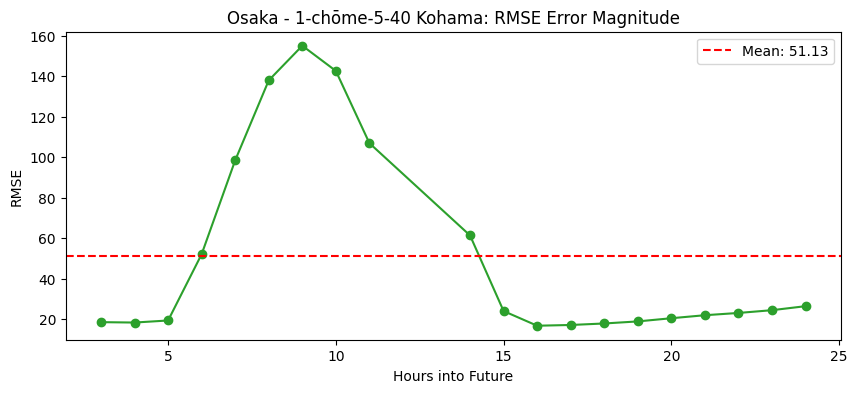

--- Validating Pretoria - North Suburb ---


Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
13:39:02 - cmdstanpy - INFO - Chain [1] start processing
13:39:02 - cmdstanpy - INFO - Chain [1] done processing
13:39:02 - cmdstanpy - INFO - Chain [1] start processing
13:39:02 - cmdstanpy - INFO - Chain [1] start processing
13:39:02 - cmdstanpy - INFO - Chain [1] done processing
13:39:02 - cmdstanpy - INFO - Chain [1] done processing
13:39:02 - cmdstanpy - INFO - Chain [1] start processing
13:39:02 - cmdstanpy - INFO - Chain [1] done processing
13:39:03 - cmdstanpy - INFO - Chain [1] start processing
13:39:03 - cmdstanpy - INFO - Chain [1] done processing
13:39:03 - cmdstanpy - INFO - Chain [1] start processing
13:39:03 - cmdstanpy - INFO - Chain [1] start processing
13:39:03 - cmdstanpy - INFO - Chain [1] done processing
13:39:03 - cmdstanpy - INFO - Cha

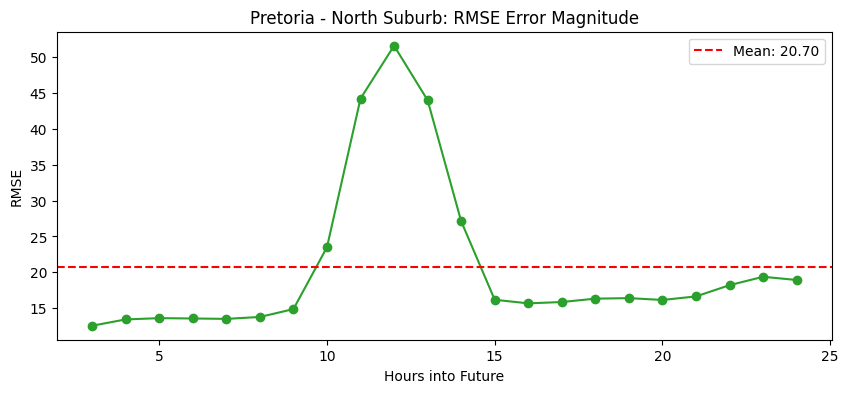

--- Validating Sydney ---


Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
13:39:12 - cmdstanpy - INFO - Chain [1] start processing
13:39:12 - cmdstanpy - INFO - Chain [1] start processing
13:39:12 - cmdstanpy - INFO - Chain [1] start processing
13:39:12 - cmdstanpy - INFO - Chain [1] done processing
13:39:12 - cmdstanpy - INFO - Chain [1] done processing
13:39:12 - cmdstanpy - INFO - Chain [1] done processing
13:39:12 - cmdstanpy - INFO - Chain [1] start processing
13:39:13 - cmdstanpy - INFO - Chain [1] done processing
13:39:13 - cmdstanpy - INFO - Chain [1] start processing
13:39:13 - cmdstanpy - INFO - Chain [1] start processing
13:39:13 - cmdstanpy - INFO - Chain [1] start processing
13:39:13 - cmdstanpy - INFO - Chain [1] done processing
13:39:13 - cmdstanpy - INFO - Chain [1] done processing
13:39:13 - cmdstanpy - INFO - Cha

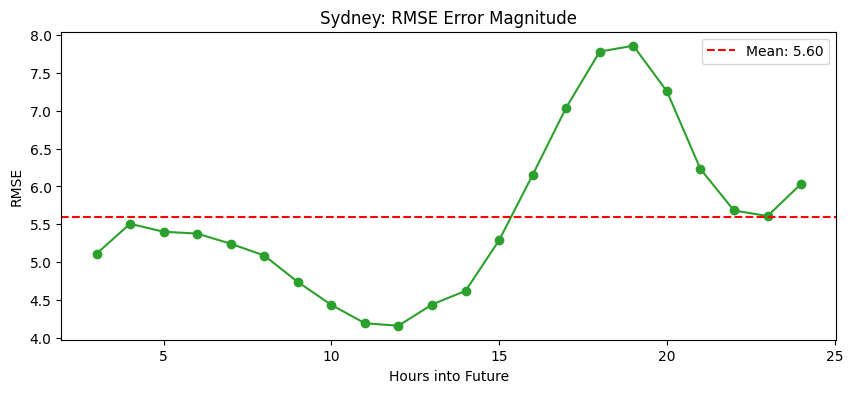


--- Global Predictability Ranking ---
                               City  Avg RMSE       MAE
                             Sydney  5.601317  4.273445
Lagos - LASWA Five Cowries Terminal  8.082189  5.773408
               London - Westminster  8.181320  6.420941
                New York - Brooklyn  9.562418  5.977333
                             Manaus 10.075349  7.613812
            Pretoria - North Suburb 20.703675 13.731824
               Beijing - Chunxiu Lu 29.282748 23.800467
        Osaka - 1-chōme-5-40 Kohama 51.125611 12.801609


In [7]:
from prophet.diagnostics import cross_validation, performance_metrics

summary_stats = []

for city, model in all_models.items():
    print(f"--- Validating {city} ---")
    try:
        # Cross-validation with a 7-day initial window and a 24-hour horizon.
        df_cv = cross_validation(model, initial='7 days', period='1 days', horizon='1 days', parallel="processes")
        df_p = performance_metrics(df_cv)

        # Focus on the Root Mean Squared Error.
        avg_rmse = df_p['rmse'].mean()
        summary_stats.append({'City': city, 'Avg RMSE': avg_rmse, 'MAE': df_p['mae'].mean()})
        
        # Plot Root Mean Squared over the 24h horizon.
        plt.figure(figsize=(10, 4))
        plt.plot(df_p['horizon'].dt.total_seconds() / 3600, df_p['rmse'], marker='o', color='#2ca02c')
        plt.title(f"{city}: RMSE Error Magnitude")
        plt.axhline(y=avg_rmse, color='r', linestyle='--', label=f'Mean: {avg_rmse:.2f}')
        plt.ylabel("RMSE")
        plt.xlabel("Hours into Future")
        plt.legend()
        plt.show()
    except Exception as e:
        print(f"❌ Could not validate {city}: {e}")

# Display ranking
df_ranking = pd.DataFrame(summary_stats).sort_values('Avg RMSE')
print("\n--- Global Predictability Ranking ---")
print(df_ranking.to_string(index=False))